<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%9610_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Варіант 8

#Загинайко Павло ФІТ 2-17

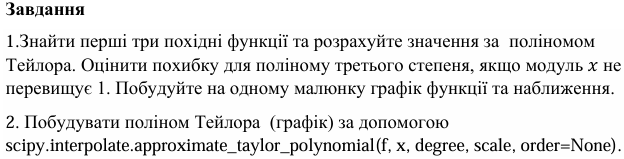

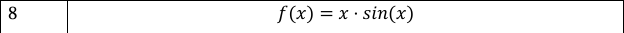

#1. Знайти перші три похідні функції та розрахуйте значення за  поліномом Тейлора. Оцінити похибку для поліному третього степеня, якщо модуль 𝑥 не перевищує 1. Побудуйте на одному малюнку графік функції та наближення.

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Задаємо символьну змінну x та функцію f(x)

Похідні:
f'(x) = x*cos(x) + sin(x)
f''(x) = -x*sin(x) + 2*cos(x)
f'''(x) = -x*cos(x) - 3*sin(x)
------------------------------
f(0) = 0
T(x) = 1.0*x**2


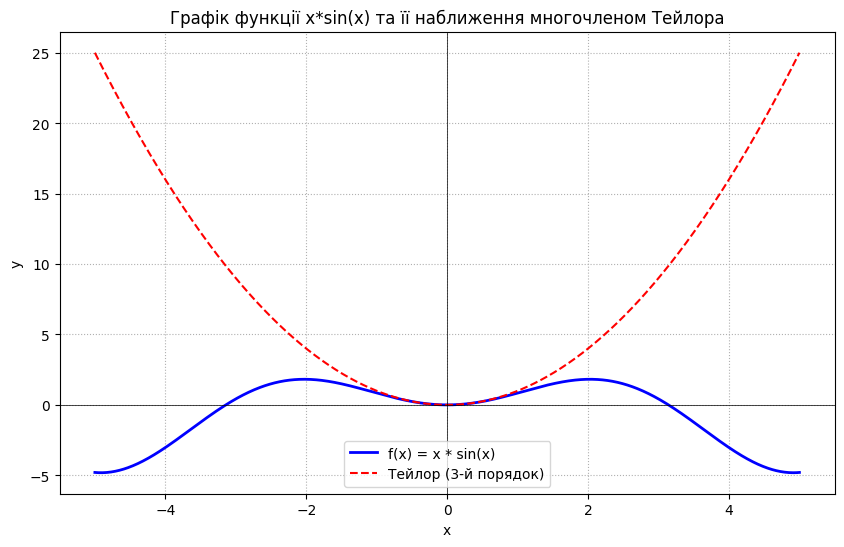

In [5]:
x = sp.symbols('x')
f = x * sp.sin(x)

# Знаходимо перші три похідні
f1 = sp.diff(f, x)
f2 = sp.diff(f1, x)
f3 = sp.diff(f2, x)

# Виводимо похідні
print("Похідні:")
print(f"f'(x) = {f1}")
print(f"f''(x) = {f2}")
print(f"f'''(x) = {f3}")
print("-" * 30)

# Знаходимо значення функції та її похідних в точці x=0
x0 = 0
f_x0 = f.subs(x, x0).evalf()
f1_x0 = f1.subs(x, x0).evalf()
f2_x0 = f2.subs(x, x0).evalf()
f3_x0 = f3.subs(x, x0).evalf()

# Обчислюємо многочлен Тейлора 3-го порядку в точці x=0
# Формула: f(x0) + f'(x0)*(x-x0) + f''(x0)/2! * (x-x0)^2 + f'''(x0)/3! * (x-x0)^3
T = f_x0 + f1_x0*(x-x0) + (f2_x0/2)*(x-x0)**2 + (f3_x0/6)*(x-x0)**3

# Виводимо результати
print(f"f(0) = {f_x0.round(3)}")
print(f"T(x) = {sp.simplify(T)}")

# Будуємо графіки
x_vals = np.linspace(-5, 5, 1000)
f_vals = np.array([f.subs(x, xi).evalf() for xi in x_vals], dtype=float)
T_vals = np.array([T.subs(x, xi).evalf() for xi in x_vals], dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, f_vals, label='f(x) = x * sin(x)', color='blue', linewidth=2)
ax.plot(x_vals, T_vals, label='Тейлор (3-й порядок)', color='red', linestyle='--')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Графік функції x*sin(x) та її наближення многочленом Тейлора")

plt.grid(True, linestyle=':')
plt.show()

#2. Побудувати поліном Тейлора  (графік) за допомогою scipy.interpolate.approximate_taylor_polynomial(f, x, degree, scale, order=None).

In [2]:
from scipy.interpolate import approximate_taylor_polynomial

Многочлен Тейлора 2-го степеня:
taylor         2
0.8023 x + 2.22e-16 x + 0.03913


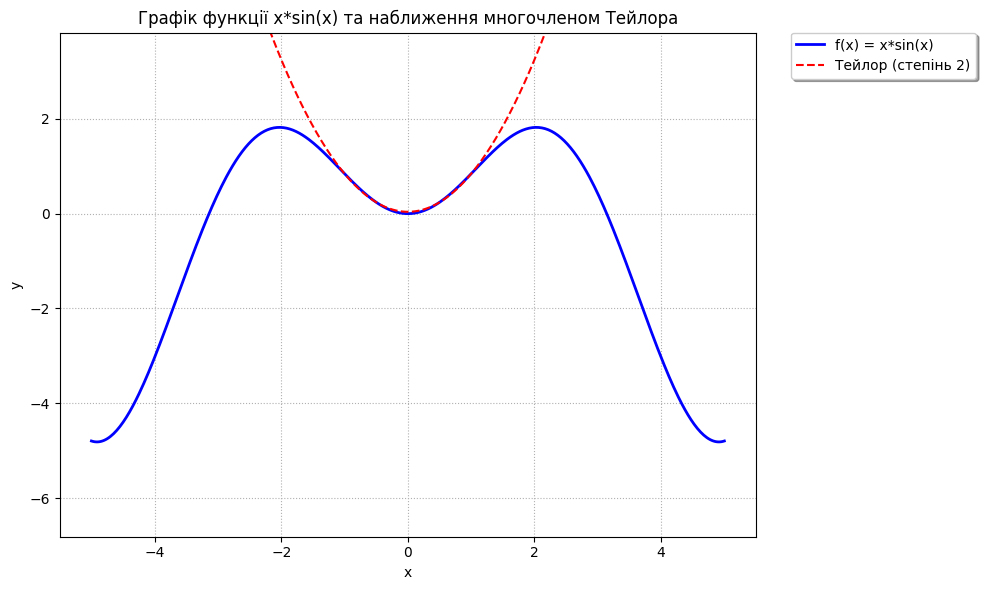

In [9]:
# Задана функція
def f(x):
    return x * np.sin(x)

# Діапазон значень для побудови графіка
x = np.linspace(-5, 5, 400)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label="f(x) = x*sin(x)", color='blue', linewidth=2)

# Точка розкладу (x0 = 0) та степінь многочлена
x0 = 0
degree = 2

# Обчислення наближення Тейлора
# scale — це крок для чисельного диференціювання
taylor = approximate_taylor_polynomial(f, 0, degree, 1)

print(f'Многочлен Тейлора {degree}-го степеня:')
print('taylor', taylor)

# Побудова графіка многочлена
plt.plot(x, taylor(x), label=f"Тейлор (степінь {degree})", color='red', linestyle='--')

# Налаштування відображення
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.0, shadow=True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Графік функції x*sin(x) та наближення многочленом Тейлора")

# Обмежимо вісь Y для кращої візуалізації, якщо Тейлор стрімко йде вгору
plt.ylim(min(f(x)) - 2, max(f(x)) + 2)
plt.tight_layout()
plt.grid(True, linestyle=':')
plt.show()